In [11]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm # Displays a progress bar

import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import Dataset, Subset, DataLoader, random_split

In [12]:
MNIST_transform = transforms.Compose([#transforms.RandomRotation(10),
    # transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.1307], [0.3081])
])
MNIST_train = datasets.MNIST('.', download=True, train = True, transform=MNIST_transform)
MNIST_test = datasets.MNIST('.', download=True, train = False, transform=MNIST_transform)
FASHION_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.2859], [0.3530])
])
FASHION_train = datasets.FashionMNIST('.', download=True, train=True, transform=MNIST_transform)
FASHION_test = datasets.FashionMNIST('.', download=True, train=False, transform=FASHION_transform)

In [13]:
class GridDataset(Dataset):
    def __init__(self, MNIST_dataset, FASHION_dataset): # pass in dataset
        assert len(MNIST_dataset) == len(FASHION_dataset)
        self.MNIST_dataset, self.FASHION_dataset = MNIST_dataset, FASHION_dataset
        self.targets = FASHION_dataset.targets
        torch.manual_seed(442) # Fix random seed for reproducibility
        N = len(MNIST_dataset)
        self.randpos = torch.randint(low=0,high=4,size=(N,)) # position of the FASHION-MNIST image
        self.randidx = torch.randint(low=0,high=N,size=(N,3)) # indices of MNIST images
    
    def __len__(self):
        return len(self.MNIST_dataset)
    
    def __getitem__(self,idx): # Get one Fashion-MNIST image and three MNIST images to make a new image
        idx1, idx2, idx3 = self.randidx[idx]
        x = self.randpos[idx]%2
        y = self.randpos[idx]//2
        p1 = self.FASHION_dataset.__getitem__(idx)[0]
        p2 = self.MNIST_dataset.__getitem__(idx1)[0]
        p3 = self.MNIST_dataset.__getitem__(idx2)[0]
        p4 = self.MNIST_dataset.__getitem__(idx3)[0]
        combo = torch.cat((torch.cat((p1,p2),2),torch.cat((p3,p4),2)),1)
        combo = torch.roll(combo, (x*28,y*28), dims=(0,1))
        return (combo,self.targets[idx])
trainset = GridDataset(MNIST_train, FASHION_train)
testset = GridDataset(MNIST_test, FASHION_test)

In [14]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: Design your own base module, define layers here
        self.base = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )
        out_channel = 256 # TODO: Put the output channel number of your base module here
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(out_channel,10)
        self.conv = nn.Conv2d(out_channel,10,1) # 1x1 conv layer (substitutes fc)

    def transfer(self): # Copy weights of fc layer into 1x1 conv layer
        self.conv.weight = nn.Parameter(self.fc.weight.unsqueeze(2).unsqueeze(3))
        self.conv.bias = nn.Parameter(self.fc.bias)

    def visualize(self,x):
        x = self.base(x)
        x = self.conv(x)
        return x
        
    def forward(self,x):
        x = self.base(x)
        x = self.avgpool(x)
        x = x.view(x.size(0),-1)
        x = self.fc(x)
        return x

In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)
testloader = DataLoader(testset, batch_size=32, shuffle=True)
model = Network().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001) # TODO: Experiment with different optimizer
num_epoch = 15 # TODO: Choose an appropriate number of epochs

In [16]:
device

'cuda'

In [17]:
def train(model, loader, num_epoch = 10): # Train the model
    print("Start training...")
    model.train() # Set the model to training mode
    for i in range(num_epoch):
        running_loss = []
        for batch, label in tqdm(loader):
            batch = batch.to(device)
            label = label.to(device)
            optimizer.zero_grad() # Clear gradients from the previous iteration
            pred = model(batch) # This will call Network.forward() that you implement
            loss = criterion(pred, label) # Calculate the loss
            running_loss.append(loss.item())
            loss.backward() # Backprop gradients to all tensors in the network
            optimizer.step() # Update trainable weights
        print("Epoch {} loss:{}".format(i+1,np.mean(running_loss))) # Print the average loss for this epoch
    print("Done!")


In [18]:
def evaluate(model, loader): # Evaluate accuracy on validation / test set
    model.eval() # Set the model to evaluation mode
    correct = 0
    with torch.no_grad(): # Do not calculate grident to speed up computation
        for batch, label in tqdm(loader):
            batch = batch.to(device)
            label = label.to(device)
            pred = model(batch)
            correct += (torch.argmax(pred,dim=1)==label).sum().item()
    acc = correct/len(loader.dataset)
    print("Evaluation accuracy: {}".format(acc))
    return acc


In [19]:
def select_correct_image(model, loader):
    model.eval()
    correct_images = []
    with torch.no_grad():
        for idx, (batch, label) in enumerate(loader):
            batch, label = batch.to(device), label.to(device)
            pred = torch.argmax(model(batch), dim=1)
            correct = (pred == label)
            for i in range(len(correct)):
                if correct[i]:
                    correct_images.append((batch[i].cpu(), label[i].cpu(), idx))
                    break  # Select only one correctly classified image
            if correct_images:
                break
    return correct_images[0]  # Return the first correctly classified image

def visualize_activation_map(model, image, label):
    # Convert model for visualization and get the activations
    model.transfer()
    activations = model.visualize(image.unsqueeze(0).to(device)).cpu().detach().numpy()
    
    # Plot the original image
    plt.figure(figsize=(6, 6))
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Image Label: {label}")
    plt.axis('off')
    plt.show()
    
    # Plot the activation maps for each class
    fig, axs = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle("Activation Maps for Each Class")
    for i, ax in enumerate(axs.flat):
        im = ax.imshow(activations[0, i], cmap='hot')
        ax.set_title(f"Class {i}")
        ax.axis('off')
    plt.colorbar(im, ax=axs.ravel().tolist())
    plt.show()


In [20]:
train(model, trainloader, num_epoch=20)
accuracy = evaluate(model, testloader)

Start training...


100%|██████████| 1875/1875 [00:54<00:00, 34.22it/s]


Epoch 1 loss:1.12091253379186


100%|██████████| 1875/1875 [00:55<00:00, 34.09it/s]


Epoch 2 loss:0.7000874784310659


...

Epoch 19 loss:0.23097830348114173


100%|██████████| 1875/1875 [00:54<00:00, 34.20it/s]


Epoch 20 loss:0.22300360109061002
Done!


100%|██████████| 313/313 [00:08<00:00, 36.18it/s]

Evaluation accuracy: 0.7181


Selected Correctly Classified Image Index: 0


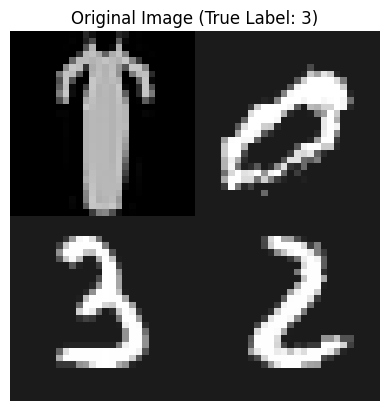

In [11]:
image, label, index = select_correct_image(model, testloader)
print(f"Selected Correctly Classified Image Index: {index}")
plt.imshow(image.squeeze().cpu(), cmap='gray')
plt.title(f"Original Image (True Label: {label})")
plt.axis('off')
plt.show()

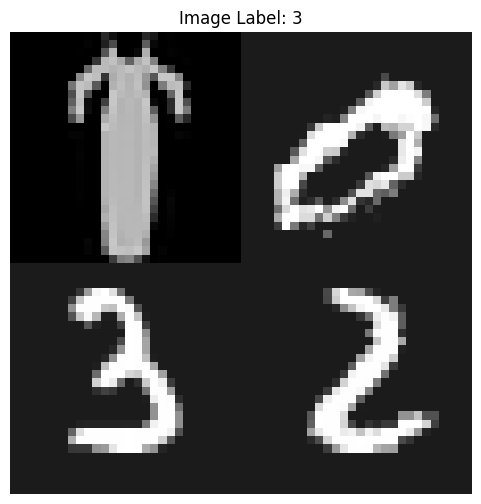

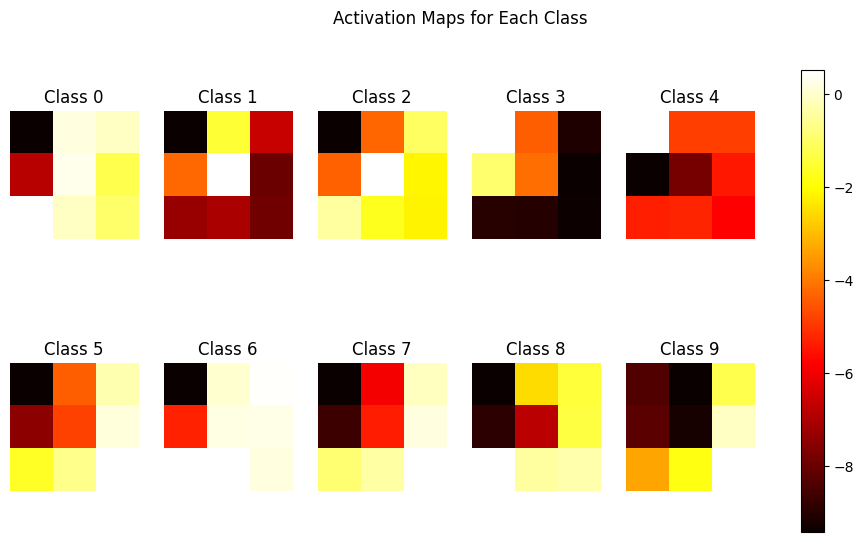

In [12]:
visualize_activation_map(model, image, label)
